In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/yaciiki/windows-1/windows_1s_all.csv


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [7]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/yaciiki/windows-1/windows_1s_all.csv")
print(df.shape)      # should be ~1800 rows
print(df.columns)    # CRITICAL: tell Khaled what these are, and which ones are important for the model
print(df.head())       # CRITICAL: tell Khaled what these columns mean, and which ones are important for the model

(1797, 21)
Index(['sec', 'packets', 'bytes', 'unique_src', 'tcp_packets', 'udp_packets',
       'icmp_packets', 'syn_packets', 'ack_packets', 'rst_packets', 'pps',
       'bps', 'syn_ratio', 'udp_ratio', 'label', 'scenario', 'attack_driver',
       'normal_traffic', 'c2_controlled', 'capture_point', 'pcap_file'],
      dtype='object')
          sec  packets   bytes  unique_src  tcp_packets  udp_packets  \
0  1777744465     5916  378624          46         5916            0   
1  1777744466     9002  576128          46         9002            0   
2  1777744467     5770  369280          46         5770            0   
3  1777744468     3448  220672          46         3448            0   
4  1777744469     3448  220672          46         3448            0   

   icmp_packets  syn_packets  ack_packets  rst_packets  ...      bps  \
0             0         5916            0         2958  ...  3028992   
1             0         9002            0         4501  ...  4609024   
2             

In [25]:

# Count NaNs per column
nan_counts = df.isnull().sum()

# Only show columns that have NaNs
nan_counts = nan_counts[nan_counts > 0]

if nan_counts.empty:
    print("No NaN values found in any column.")
else:
    print("NaN counts per feature:")
    print(nan_counts.sort_values(ascending=False))
    print(f"\nTotal columns with NaNs: {len(nan_counts)}")


NaN counts per feature:
syn_ratio         531
attack_driver     293
normal_traffic    126
dtype: int64

Total columns with NaNs: 3


In [26]:
df['syn_ratio'] = df['syn_ratio'].fillna(0)
df['udp_ratio'] = df['udp_ratio'].fillna(0)
df['normal_traffic'] = df['normal_traffic'].fillna("off")

# Check what remains
print(df.isnull().sum())


sec                  0
packets              0
bytes                0
unique_src           0
tcp_packets          0
udp_packets          0
icmp_packets         0
syn_packets          0
ack_packets          0
rst_packets          0
pps                  0
bps                  0
syn_ratio            0
udp_ratio            0
label                0
scenario             0
attack_driver      293
normal_traffic       0
c2_controlled        0
capture_point        0
pcap_file            0
is_attack            0
predicted            0
predicted_multi      0
dtype: int64


In [28]:
df['is_attack'] = (df['label'] != 'normal').astype(int)

# Features to use
feature_cols = ['packets', 'bytes', 'unique_src', 'tcp_packets', 'udp_packets',
                'icmp_packets', 'syn_packets', 'ack_packets', 'rst_packets',
                'pps', 'bps', 'syn_ratio', 'udp_ratio']
df['syn_ratio'] = df['syn_ratio'].fillna(0)
df['udp_ratio'] = df['udp_ratio'].fillna(0)
df['normal_traffic'] = df['normal_traffic'].fillna("off")

# Check what remains
print(df.isnull().sum())


# 1. Class distribution
print("=== LABEL DISTRIBUTION ===")
print(df['label'].value_counts())

# 2. Binary distribution
print("\n=== BINARY ===")
print(df['is_attack'].value_counts())

# 3. Mean features per label
print("\n=== MEAN FEATURES PER LABEL ===")
print(df.groupby('label')[feature_cols].mean().round(1))

# 4. The key question: what separates normal from attack?
normal = df[df['label'] == 'normal']
attack = df[df['label'] != 'normal']

print("\n=== NORMAL vs ATTACK ===")
for col in feature_cols:
    n_mean = normal[col].mean()
    a_mean = attack[col].mean()
    diff = a_mean - n_mean
    print(f"{col:15s}  normal={n_mean:>12.1f}  attack={a_mean:>12.1f}  diff={diff:>12.1f}")


sec                  0
packets              0
bytes                0
unique_src           0
tcp_packets          0
udp_packets          0
icmp_packets         0
syn_packets          0
ack_packets          0
rst_packets          0
pps                  0
bps                  0
syn_ratio            0
udp_ratio            0
label                0
scenario             0
attack_driver      293
normal_traffic       0
c2_controlled        0
capture_point        0
pcap_file            0
is_attack            0
predicted            0
predicted_multi      0
dtype: int64
=== LABEL DISTRIBUTION ===
label
attack         773
mixed          341
normal          74
http-high       61
http-low        61
icmp            61
http-medium     61
tcp-low         61
tcp-medium      61
udp-medium      61
udp-high        61
udp-low         61
tcp-high        60
Name: count, dtype: int64

=== BINARY ===
is_attack
1    1723
0      74
Name: count, dtype: int64

=== MEAN FEATURES PER LABEL ===
             packets    

In [8]:
print(df['label'].value_counts())
print("\n--- Scenarios ---")
print(df['scenario'].value_counts())
print("\n--- Attack drivers ---")
print(df['attack_driver'].value_counts())
print("\n--- Normal traffic ON vs OFF ---")
print(df['normal_traffic'].value_counts())
print("\n--- Capture points ---")
print(df['capture_point'].value_counts())

label
attack         773
mixed          341
normal          74
http-high       61
http-low        61
icmp            61
http-medium     61
tcp-low         61
tcp-medium      61
udp-medium      61
udp-high        61
udp-low         61
tcp-high        60
Name: count, dtype: int64

--- Scenarios ---
scenario
mixed          373
http-high      124
http-medium    123
icmp           123
udp-medium     123
udp-high       122
http-low       122
udp-low        122
low            122
high            94
medium          93
normal          74
tcp-low         61
tcp-medium      61
tcp-high        60
Name: count, dtype: int64

--- Attack drivers ---
attack_driver
hping3    834
c2        670
Name: count, dtype: int64

--- Normal traffic ON vs OFF ---
normal_traffic
on    1671
Name: count, dtype: int64

--- Capture points ---
capture_point
Rdc-eth0    1797
Name: count, dtype: int64


In [12]:
# These are your actual features for detection
feature_cols = ['packets', 'bytes', 'unique_src', 'tcp_packets', 'udp_packets',
                'icmp_packets', 'syn_packets', 'ack_packets', 'rst_packets',
                'pps', 'bps', 'syn_ratio', 'udp_ratio']

# Metadata (not used as features, but useful for analysis)
meta_cols = ['sec', 'label', 'scenario', 'attack_driver',
             'normal_traffic', 'c2_controlled', 'capture_point', 'pcap_file']
print(df.groupby('label')[feature_cols].mean().round(1))


             packets      bytes  unique_src  tcp_packets  udp_packets  \
label                                                                   
attack       18787.2  2345509.9        44.1      14647.6       2556.8   
http-high     3295.3   210900.5        46.0       3295.3          0.0   
http-low      2213.1   141639.3        46.0       2213.1          0.0   
http-medium   3597.2   230222.8        46.0       3597.2          0.0   
icmp          2801.3   274526.9        46.0          0.0          0.0   
mixed        12162.7  1023309.4        23.6      10241.0        702.0   
normal          51.4     4814.0         5.2         51.4          0.0   
tcp-high      3131.9   200451.7        46.0       3131.9          0.0   
tcp-low       4055.1   259535.3        46.0       4055.1          0.0   
tcp-medium    3846.3   246166.5        46.0       3846.3          0.0   
udp-high      3084.4  1708944.3        45.6          0.0       3078.3   
udp-low       3959.4  2194538.8        46.0        

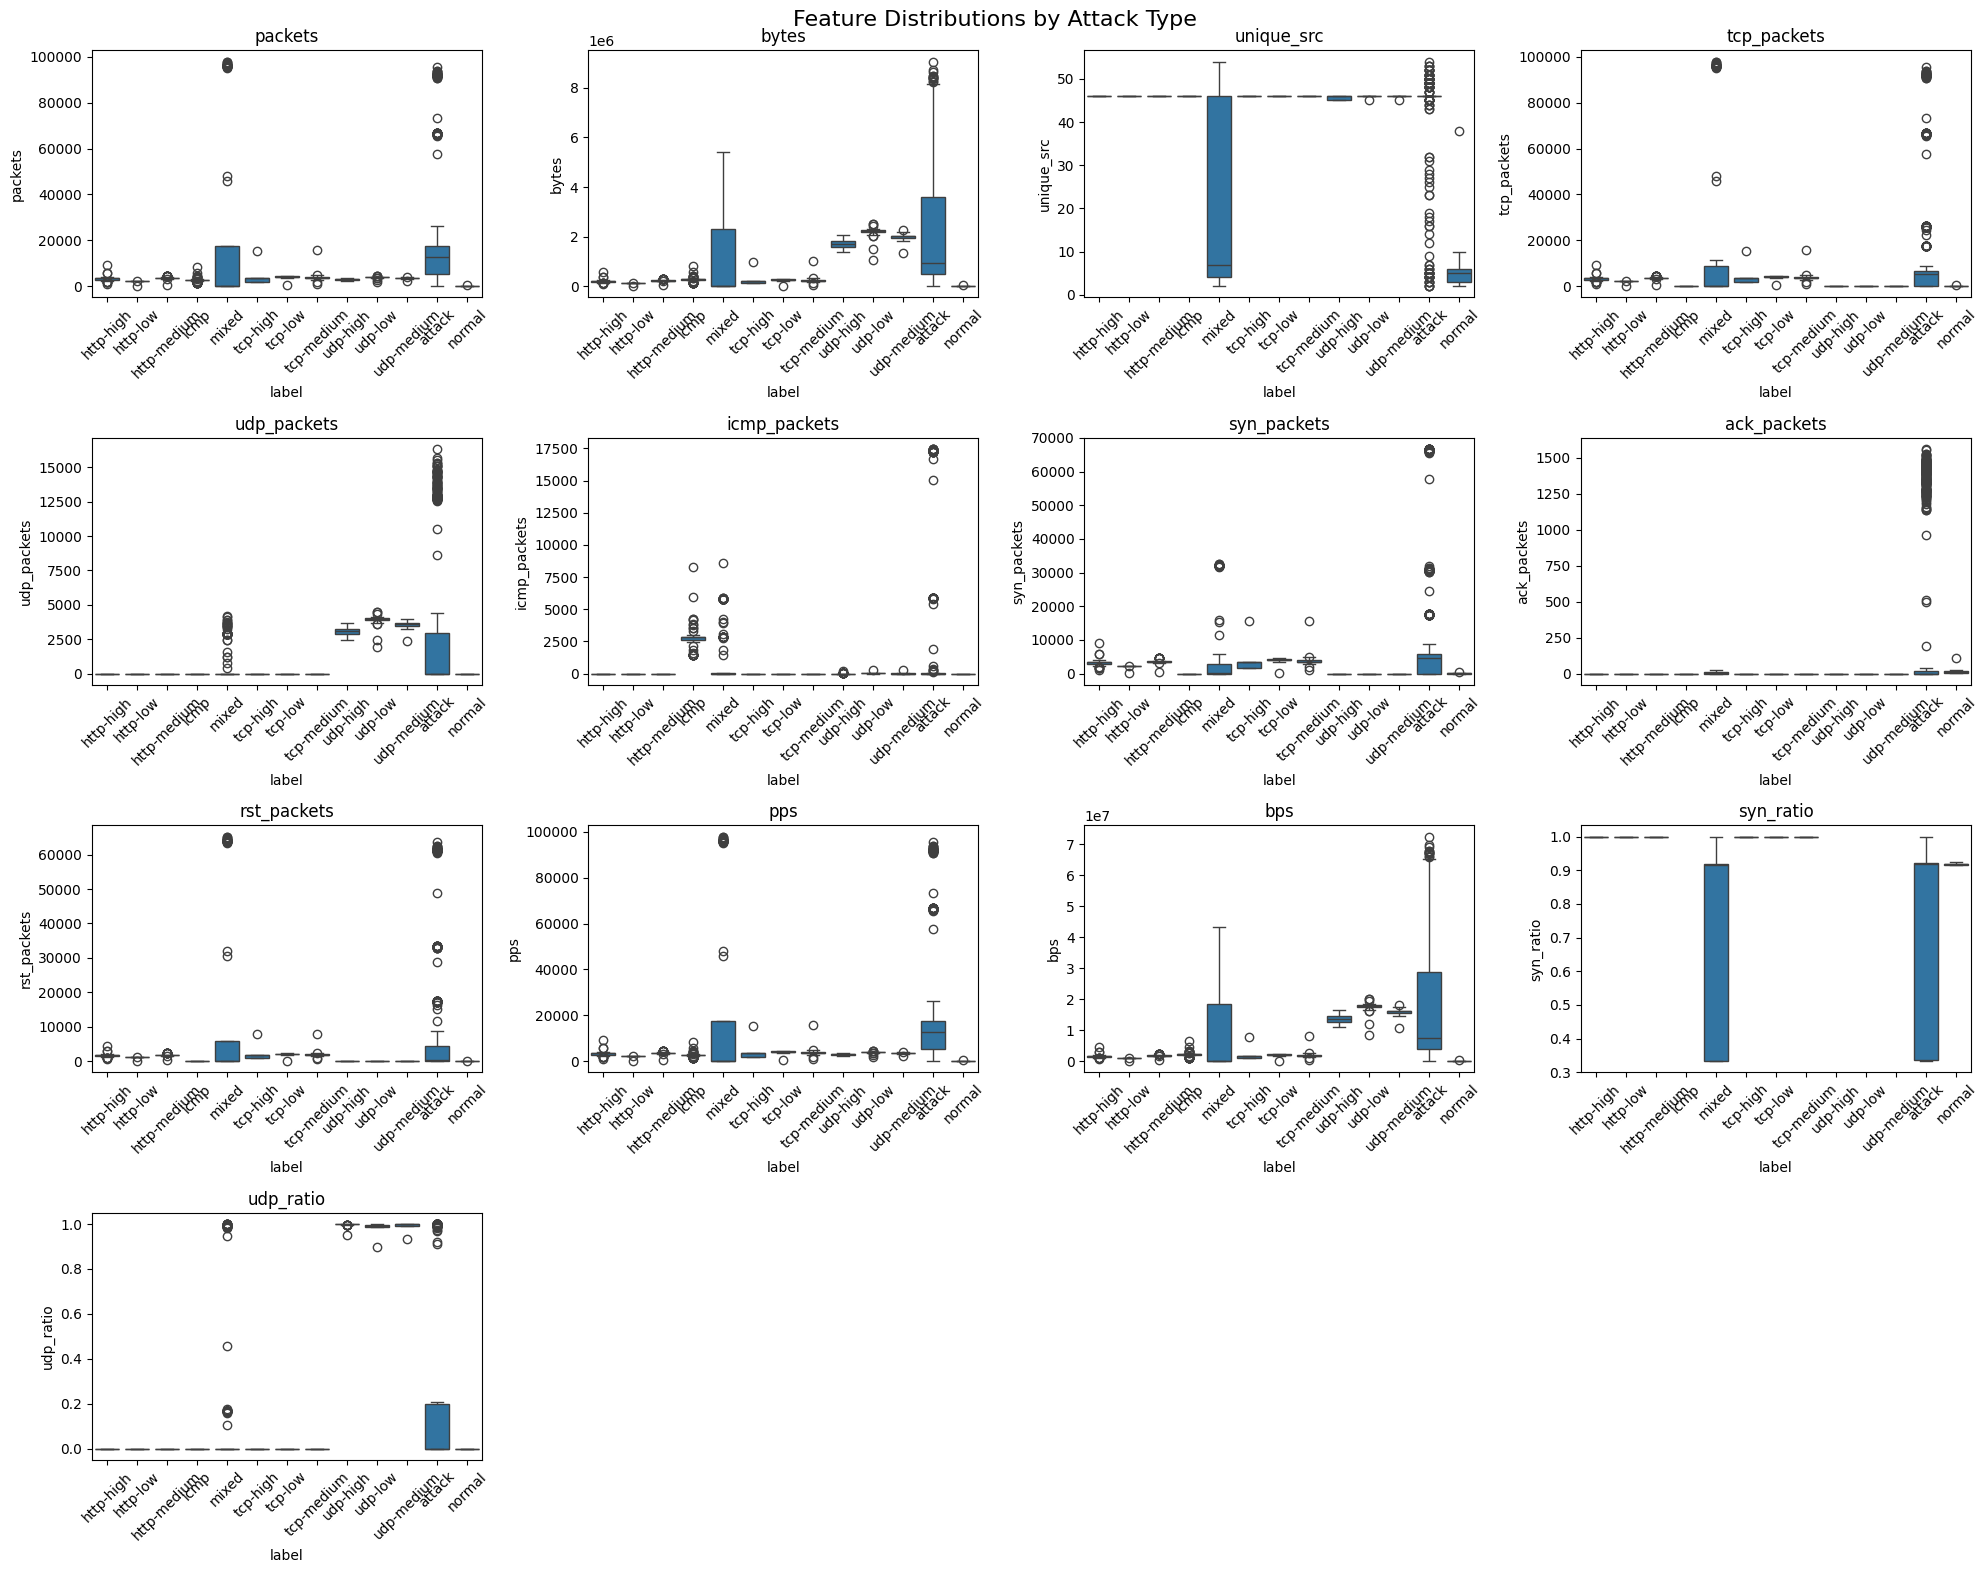

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create plots directory if it doesn't exist
os.makedirs('plots', exist_ok=True)

# Make sure feature_cols is defined
# Example: feature_cols = ['feature1', 'feature2', 'feature3', ...] 
# or exclude non-feature columns like:
# feature_cols = df.drop(['label'], axis=1).columns.tolist()

# Your plotting code
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(x='label', y=col, data=df, ax=axes[i])
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

# hide extra subplots
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Attack Type', fontsize=16)
plt.tight_layout()
plt.savefig('plots/feature_distributions.png', dpi=150)
plt.show()

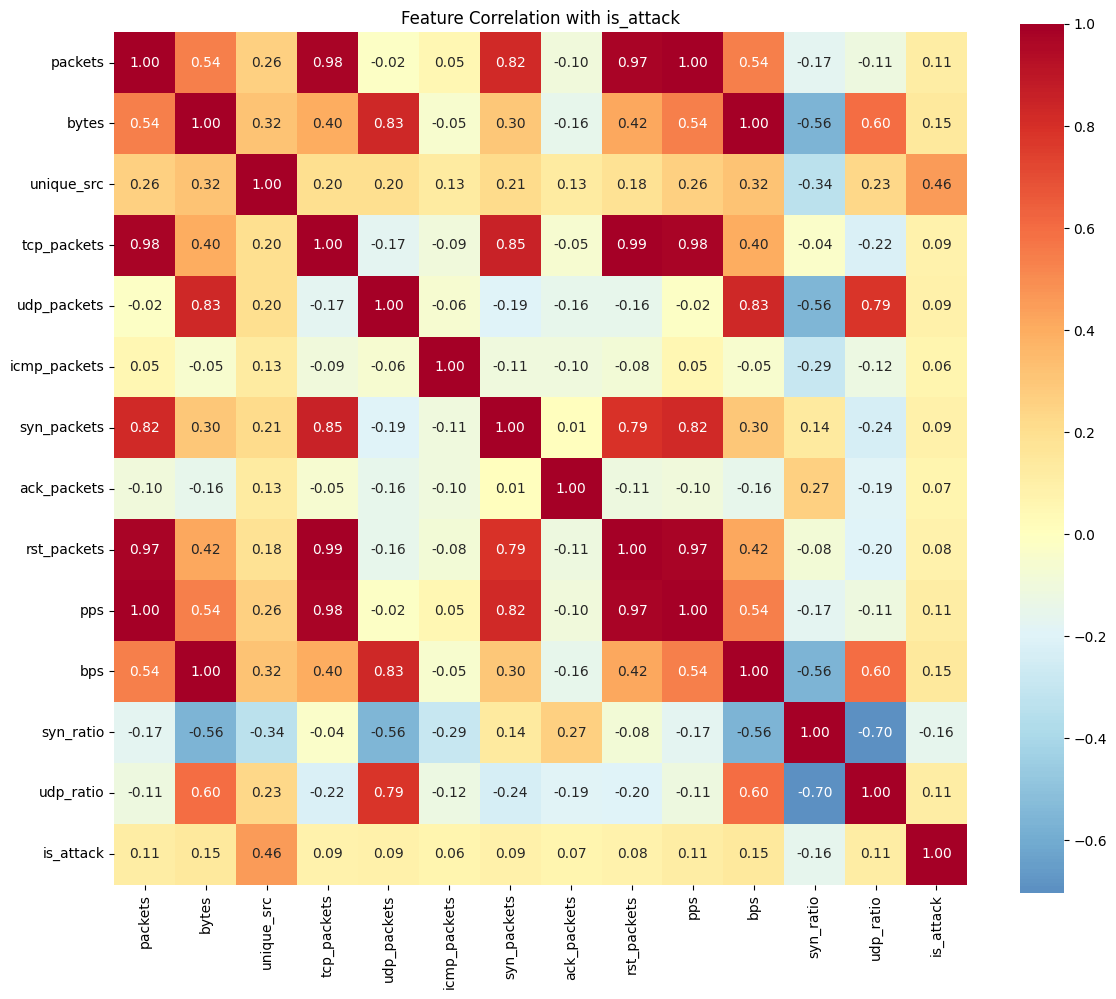

In [30]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[feature_cols + ['is_attack']].corr(), annot=True,
            cmap='RdYlBu_r', fmt='.2f', center=0, square=True)
plt.title('Feature Correlation with is_attack')
plt.tight_layout()
plt.savefig('plots/correlation_with_label.png', dpi=150)
plt.show()


In [21]:
df['is_attack'] = (df['label'] != 'normal').astype(int)
print(df['is_attack'].value_counts())


is_attack
1    1723
0      74
Name: count, dtype: int64


In [36]:

X = df[feature_cols]
y = df['is_attack']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} samples")
print(f"Test:  {len(X_test)} samples")
print(f"Train attack ratio: {y_train.mean():.2%}")
print(f"Test attack ratio:  {y_test.mean():.2%}")


Train: 1257 samples
Test:  540 samples
Train attack ratio: 95.86%
Test attack ratio:  95.93%


=== DECISION TREE ===
              precision    recall  f1-score   support

      normal       0.29      0.09      0.14        22
      attack       0.96      0.99      0.98       518

    accuracy                           0.95       540
   macro avg       0.62      0.54      0.56       540
weighted avg       0.93      0.95      0.94       540



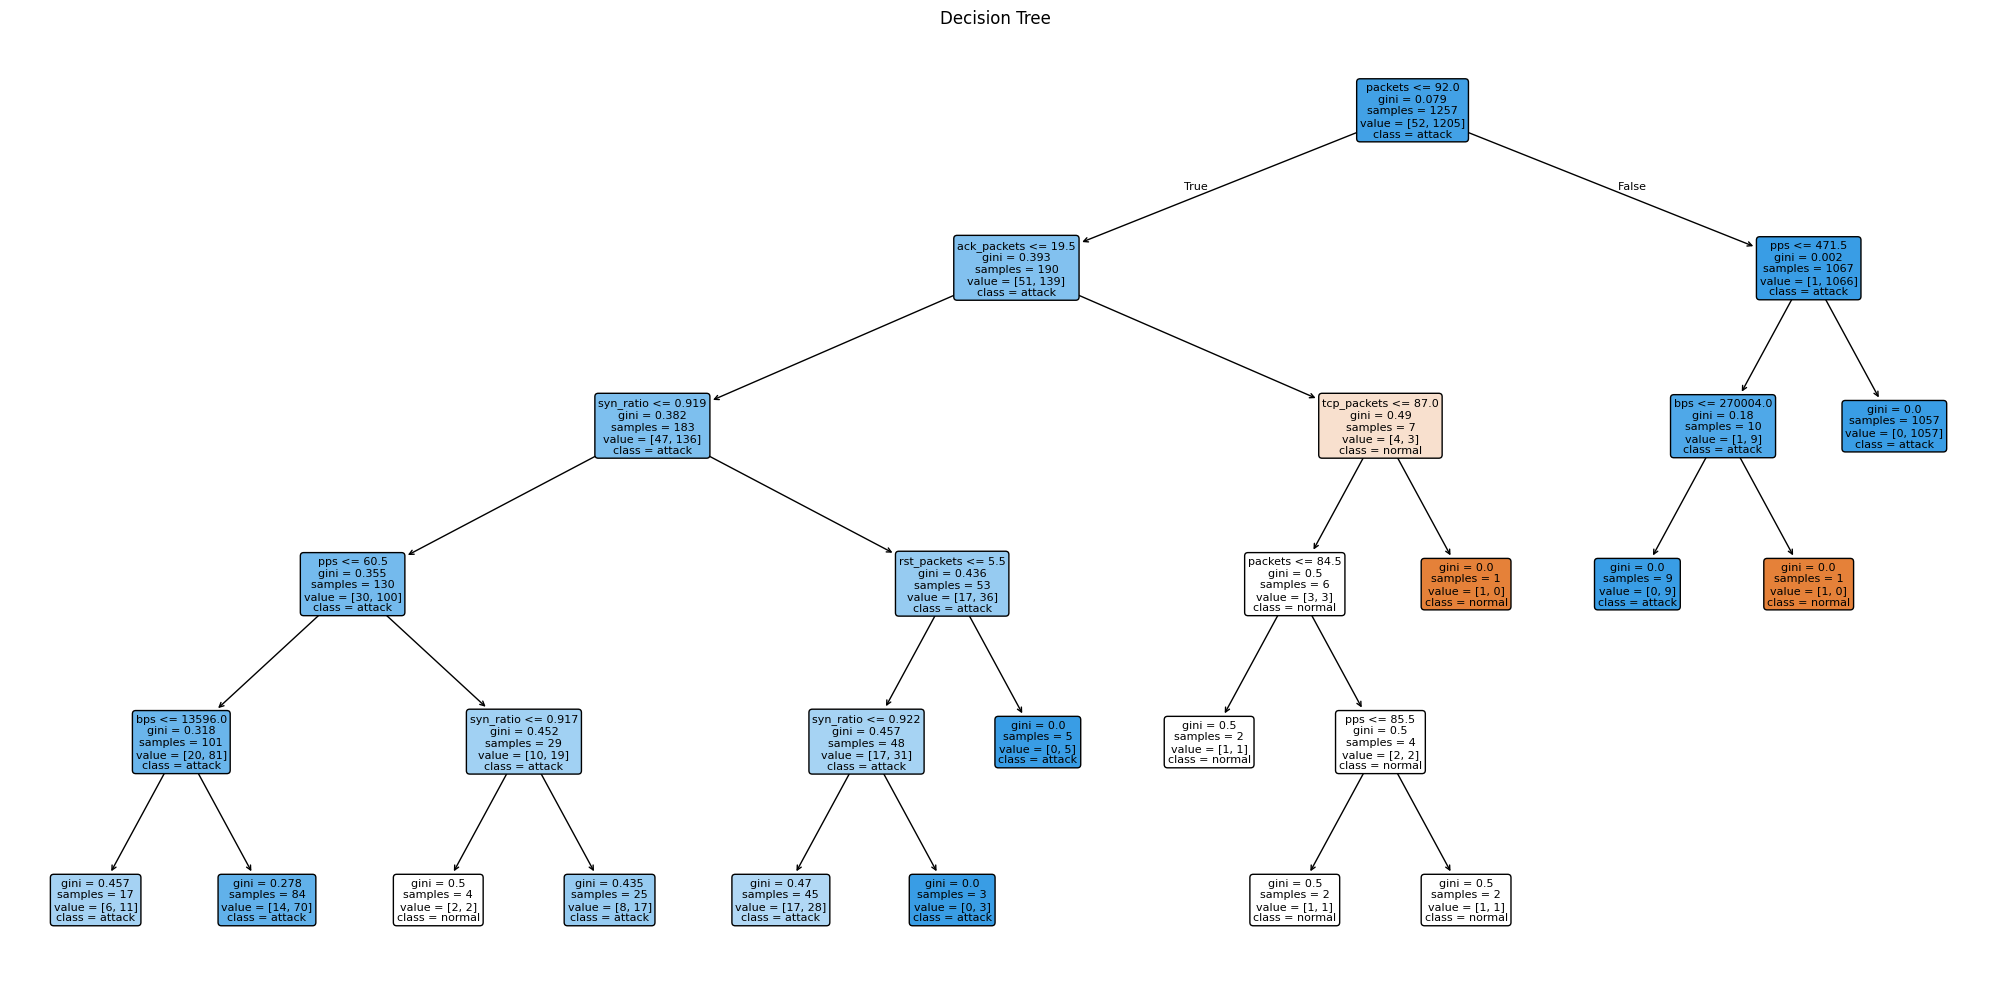

In [37]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("=== DECISION TREE ===")
print(classification_report(y_test, y_pred_dt, target_names=['normal', 'attack']))

# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=feature_cols, class_names=['normal', 'attack'],
          filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree')
plt.tight_layout()
plt.savefig('plots/decision_tree.png', dpi=150)
plt.show()


In [39]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf, target_names=['normal', 'attack']))


=== RANDOM FOREST ===
              precision    recall  f1-score   support

      normal       0.50      0.23      0.31        22
      attack       0.97      0.99      0.98       518

    accuracy                           0.96       540
   macro avg       0.73      0.61      0.65       540
weighted avg       0.95      0.96      0.95       540



In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Your threshold detector
threshold = df[df['label'] == 'normal']['pps'].mean() + 3 * df[df['label'] == 'normal']['pps'].std()
y_pred_thresh = (X_test['pps'] > threshold).astype(int)

results = pd.DataFrame({
    'Model': ['Threshold (pps only)', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_thresh),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_thresh),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_thresh),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    'F1': [
        f1_score(y_test, y_pred_thresh),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

print(results.to_string(index=False))


               Model  Accuracy  Precision   Recall       F1
Threshold (pps only)  0.862963   1.000000 0.857143 0.923077
       Decision Tree  0.953704   0.962477 0.990347 0.976213
       Random Forest  0.959259   0.967925 0.990347 0.979008


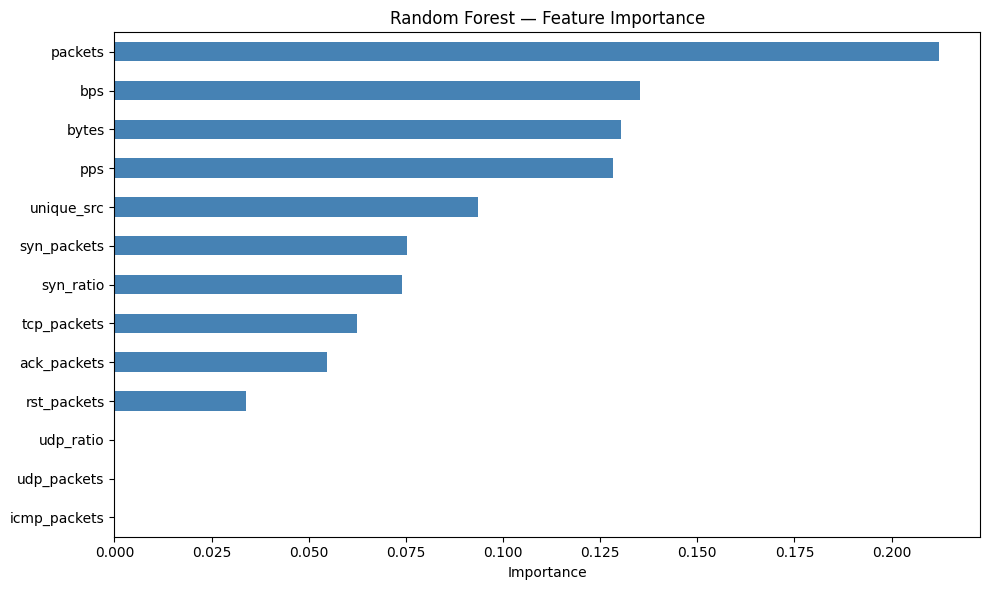

In [41]:
importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

importance.plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=150)
plt.show()


In [45]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

feature_cols = ['packets', 'bytes', 'unique_src', 'tcp_packets', 'udp_packets',
                'icmp_packets', 'syn_packets', 'ack_packets', 'rst_packets',
                'pps', 'bps', 'syn_ratio', 'udp_ratio']

X = df[feature_cols]
y = df['is_attack']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

weak_learner = DecisionTreeClassifier(max_depth=1)

ada = AdaBoostClassifier(
    estimator=weak_learner,
    n_estimators=100,       
    learning_rate=0.5,    
    random_state=42
)

ada.fit(X_train, y_train)

print("=== ADABOOST ===")
print(classification_report(y_test, ada.predict(X_test),
                            target_names=['normal', 'attack']))


=== ADABOOST ===
              precision    recall  f1-score   support

      normal       0.00      0.00      0.00        22
      attack       0.96      1.00      0.98       518

    accuracy                           0.96       540
   macro avg       0.48      0.50      0.49       540
weighted avg       0.92      0.96      0.94       540



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
